# `status_group`: initial label audit

This notebook looks only at the Pump It Up training label. It establishes the label's integrity, class distribution and simplest possible prediction reference before any feature processing or modelling.

Questions for this first pass:

1. Is there exactly one non-missing label for every training ID?
2. Are the three documented classes the only observed values?
3. How imbalanced is the target?
4. What accuracy would the majority-class non-model achieve?
5. What constraints does this place on splitting and later evaluation?

## 1. Set up and load the labels

Load only `TrainingSetLabels.csv`. Feature relationships belong in later focused audits, not in this initial look at the target itself.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

source_directory = str(Path("../src").resolve())
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from source_data_validation import validate_label_frame

labels_path = Path("../data/TrainingSetLabels.csv")
if not labels_path.is_file():
    raise FileNotFoundError(f"Training labels not found: {labels_path}")

training_labels = pd.read_csv(labels_path)
validate_label_frame(training_labels)
target = training_labels["status_group"]


## 2. Check label integrity

The shared validator covers DataFrame structure and identifier integrity. Check the target column itself for missing, blank or undocumented values.

In [2]:
expected_labels = {
    "functional",
    "functional needs repair",
    "non functional",
}
actual_labels = set(target.dropna().unique())

missing_expected_labels = sorted(expected_labels - actual_labels)
unexpected_labels = sorted(actual_labels - expected_labels)
if missing_expected_labels or unexpected_labels:
    raise ValueError(
        "Observed labels do not match the documented classes; "
        f"missing={missing_expected_labels!r}, "
        f"unexpected={unexpected_labels!r}."
    )

blank_label_count = int(
    target.astype("string").str.strip().eq("").sum()
)

label_integrity = pd.Series({
    "rows": len(training_labels),
    "unique IDs": training_labels["id"].nunique(),
    "missing IDs": int(training_labels["id"].isna().sum()),
    "duplicate IDs": int(training_labels["id"].duplicated().sum()),
    "missing labels": int(target.isna().sum()),
    "blank labels": blank_label_count,
    "observed classes": target.nunique(),
}, name="value").to_frame()

label_integrity


,value
rows,59400
unique IDs,59400
missing IDs,0
duplicate IDs,0
missing labels,0
blank labels,0
observed classes,3


### Observation

`TrainingSetLabels.csv` contains 59,400 rows and 59,400 unique IDs. There are no null or duplicate IDs, no missing or blank target values, and the observed values are exactly the three documented classes. No label cleaning is justified at this stage.

## 3. Measure the class distribution

Keep a semantic class order rather than relying on alphabetical or frequency order. `value_counts` is the pandas equivalent of grouping by the label and counting the rows.

In [3]:
label_order = [
    "functional",
    "functional needs repair",
    "non functional",
]

label_summary = (
    target.value_counts()
    .reindex(label_order)
    .rename("count")
    .to_frame()
)
label_summary["percentage"] = (
    label_summary["count"] / len(target) * 100
)

label_summary_display = label_summary.copy()
label_summary_display["percentage"] = (
    label_summary_display["percentage"].round(2)
)
label_summary_display


,count,percentage
status_group,,
functional,32259,54.31
functional needs repair,4317,7.27
non functional,22824,38.42


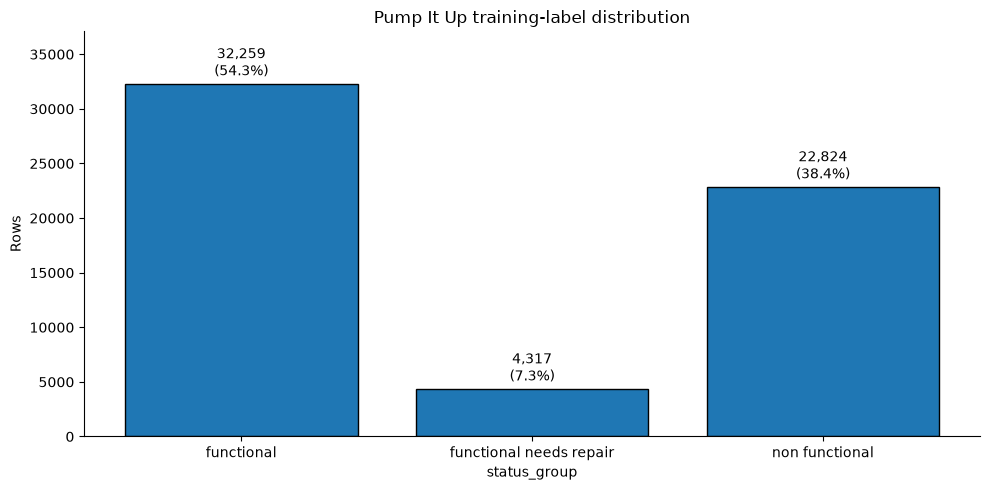

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    label_summary.index,
    label_summary["count"],
    edgecolor="black",
)

bar_labels = [
    f"{int(row['count']):,}\n({row['percentage']:.1f}%)"
    for _, row in label_summary.iterrows()
]
ax.bar_label(bars, labels=bar_labels, padding=3)
ax.set_title("Pump It Up training-label distribution")
ax.set_xlabel("status_group")
ax.set_ylabel("Rows")
ax.set_ylim(0, label_summary["count"].max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


## 4. Establish the non-model reference

A classifier that always predicts the most frequent class is the minimum accuracy reference. It is not a useful model, but a trained model that cannot beat it has not extracted useful signal.

In [5]:
majority_label = label_summary["count"].idxmax()
minority_label = label_summary["count"].idxmin()
majority_accuracy = label_summary.loc[majority_label, "count"] / len(target)
majority_to_minority_ratio = (
    label_summary.loc[majority_label, "count"]
    / label_summary.loc[minority_label, "count"]
)

majority_reference = pd.Series({
    "always predict": majority_label,
    "accuracy": majority_accuracy,
    "minority class": minority_label,
    "majority-to-minority ratio": majority_to_minority_ratio,
}, name="value")

majority_reference


always predict                             functional
accuracy                                     0.543081
minority class                functional needs repair
majority-to-minority ratio                    7.47255
Name: value, dtype: object

## 5. Findings and decisions

| Finding | Evidence | Consequence |
| --- | --- | --- |
| Labels are structurally complete | 59,400 unique IDs; no null, blank or undocumented labels | Keep the labels unchanged |
| `functional` is the majority class | 32,259 rows, 54.31% | Majority-class accuracy reference is 54.31% |
| `functional needs repair` is under-represented | 4,317 rows, 7.27%; majority-to-minority ratio is 7.47:1 | Use a stratified split and inspect class-level errors |
| `non functional` remains substantial | 22,824 rows, 38.42% | Overall accuracy is meaningful but insufficient on its own for diagnosis |

Decisions for the next stage:

1. Stratify the train/validation split by `status_group`.
2. Use challenge accuracy as the primary comparison measure, but also inspect the confusion matrix and per-class recall so minority-class failure is visible.
3. Keep the target as its three meaningful string labels until an estimator requires another representation.
4. Do not oversample or calculate class weights before the split. Any later balancing treatment must be fitted to training data only and justified by validation results.
5. Move next to identifier alignment and creation of the reproducible stratified split; do not inspect feature-to-target relationships using the future validation partition.